In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("glass.csv")
df.head()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
df.columns = [
    'ri','na','mg','al','si','k','ca','ba','fe','glass_type'
]


In [ ]:
df['Window'] = df['glass_type'].map({
    1:0, 2:0, 3:0, 4:0,
    5:1, 6:1, 7:1
})

df[['glass_type', 'Window']].head()


,glass_type,Window
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [ ]:
X = df[['ri','mg','al','k','ca']].values
y = df['Window'].values.reshape(-1, 1)

X.shape, y.shape


((214, 5), (214, 1))

In [ ]:
X = (X - X.mean(axis=0)) / X.std(axis=0)


In [ ]:
np.random.seed(42)

m = X.shape[0]
indices = np.random.permutation(m)

train_size = int(0.8 * m)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_train.shape, X_test.shape


((171, 5), (43, 5))

In [ ]:
class LogisticRegressionSLPNN:

    def __init__(self, lr):
        self.lr = lr
        self.w = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y, epochs):
        n_samples, n_features = X.shape
        self.w = np.zeros((n_features, 1))

        for epoch in range(epochs):

            z = np.dot(X, self.w)
            y_hat = self.sigmoid(z)

            loss = (-y*np.log(y_hat + 1e-9) -
                    (1 - y)*np.log(1 - y_hat + 1e-9)).mean()
            self.losses.append(loss)

            dw = np.dot(X.T, (y_hat - y)) / n_samples
            self.w -= self.lr * dw

            if epoch % 1000 == 0:
                print(f"Epoch {epoch}, Loss: {loss}")

    def predict(self, X):
        probs = self.sigmoid(np.dot(X, self.w))
        return (probs >= 0.5).astype(int)


In [ ]:
model = LogisticRegressionSLPNN(lr=0.05)
model.fit(X_train, y_train, epochs=10000)


Epoch 0, Loss: 0.6931471785599453
Epoch 1000, Loss: 0.27256117101177285
Epoch 2000, Loss: 0.24613554486003872
Epoch 3000, Loss: 0.23367573537566108
Epoch 4000, Loss: 0.22666409835309406
Epoch 5000, Loss: 0.2223845473484323
Epoch 6000, Loss: 0.2196225883542823
Epoch 7000, Loss: 0.21776828749299704
Epoch 8000, Loss: 0.21648904258370194
Epoch 9000, Loss: 0.21558940874811058


In [ ]:
train_accuracy = (model.predict(X_train) == y_train).mean()
test_accuracy = (model.predict(X_test) == y_test).mean()

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)


Training Accuracy: 0.9415204678362573
Test Accuracy: 0.8837209302325582


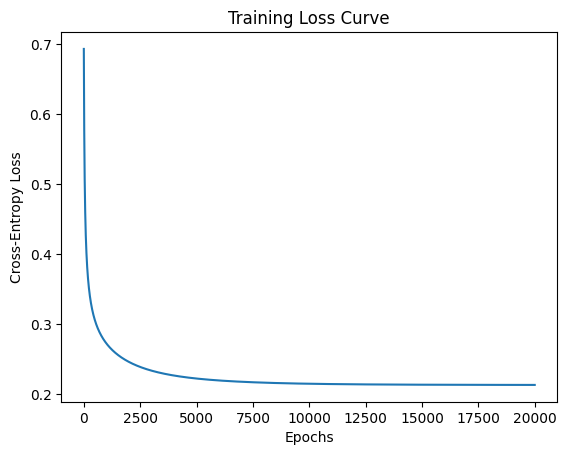

In [ ]:
plt.plot(model.losses)
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.show()
